# ML para predecir tiempo de viaje


## 1. Cargar

In [1]:
import datetime

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/sample/2025-04-21_sample.csv")
df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,1,2025-04-21 08:48:04,2025-04-21 08:50:39,155,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853,825,347180,6301636,347201,6302489
1,BUS,1,2025-04-21 08:51:46,2025-04-21 08:54:58,192,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090,983,347200,6302473,346625,6303299
2,BUS,1,2025-04-21 15:34:28,2025-04-21 15:39:01,273,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127,959,346563,6303315,347168,6302522
3,METRO,0,2025-04-21 17:27:55,-,-,LAS CONDES,-,LOS DOMINICOS,-,-,-,356329,6302427,-,-
4,METRO,1,2025-04-21 09:12:16,2025-04-21 09:38:40,1584,ESTACION CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240,3064,343933,6297455,346372,6299031


## 2. Limpieza y Transformacion

In [3]:
df.replace("-", np.nan, inplace=True)

# limpieza con comunas con tilde
comunas_con_tilde = {
    "SAN JOAQUIN": "SAN JOAQUÍN",
    "SAN RAMON": "SAN RAMÓN",
    "PENALOLEN": "PEÑALOLÉN",
    "NUNOA": "ÑUÑOA",
    "MAIPU": "MAIPÚ",
    "CONCHALI": "CONCHALÍ",
    "ESTACION CENTRAL": "ESTACIÓN CENTRAL"
}
def comunas_map(comuna):
    if comuna in comunas_con_tilde:
        return comunas_con_tilde[comuna]
    return comuna
df["comuna_subida"] = df["comuna_subida"].map(comunas_map)
df["comuna_bajada"] = df["comuna_bajada"].map(comunas_map)

In [4]:
transfo_df = df.copy()
transfo_df["tiempo_subida"] = pd.to_datetime(transfo_df["tiempo_subida"])
transfo_df["tiempo_bajada"] = pd.to_datetime(transfo_df["tiempo_bajada"])

transfo_df["tipo_transporte"] = transfo_df["tipo_transporte"].astype("category")
transfo_df["comuna_subida"] = transfo_df["comuna_subida"].astype("category")
transfo_df["comuna_bajada"] = transfo_df["comuna_bajada"].astype("category")
transfo_df["parada_bajada"] = transfo_df["parada_bajada"].astype("category")
transfo_df["parada_subida"] = transfo_df["parada_subida"].astype("category")

transfo_df["tiempo_etapa"] = transfo_df["tiempo_etapa"].astype(float)
transfo_df["x_bajada"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_bajada"] = transfo_df["y_bajada"].astype(float)
transfo_df["x_subida"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_subida"] = transfo_df["y_bajada"].astype(float)
transfo_df["dist_eucl_paraderos"] = transfo_df["dist_eucl_paraderos"].astype(float)
transfo_df["dist_ruta_paraderos"] = transfo_df["dist_ruta_paraderos"].astype(float)

transfo_df["tiene_bajada"] = transfo_df["tiene_bajada"].astype(bool)

transfo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tipo_transporte      5000 non-null   category      
 1   tiene_bajada         5000 non-null   bool          
 2   tiempo_subida        5000 non-null   datetime64[ns]
 3   tiempo_bajada        3795 non-null   datetime64[ns]
 4   tiempo_etapa         3795 non-null   float64       
 5   comuna_subida        4999 non-null   category      
 6   comuna_bajada        3786 non-null   category      
 7   parada_subida        4999 non-null   category      
 8   parada_bajada        3786 non-null   category      
 9   dist_ruta_paraderos  3795 non-null   float64       
 10  dist_eucl_paraderos  3795 non-null   float64       
 11  x_subida             3795 non-null   float64       
 12  y_subida             3795 non-null   float64       
 13  x_bajada             3795 non-nul

In [5]:
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0


In [6]:
def map_time_range(date):
    time = date.time()
    if (datetime.time(00, 00, 00) <= time) and (time <= datetime.time(5, 59, 59)):
        return "early"
    elif (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(11, 59, 59)):
        return "morning"
    elif (datetime.time(12, 00, 00) <= time) and (time <= datetime.time(17, 59, 59)):
        return "afternoon"
    elif (datetime.time(18, 00, 00) <= time) and (time <= datetime.time(23, 59, 59)):
        return "night"

transfo_df["time_range"] = transfo_df["tiempo_subida"].map(map_time_range)

In [7]:
def map_time_type(date):
    time = date.time()
    if (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(8, 59, 59)):
        return "rush_time-morning"
    elif (datetime.time(17, 00, 00) <= time) and (time <= datetime.time(19, 59, 59)):
        return "rush_time-night"
    else:
        return "normal"

transfo_df["time_type"] = transfo_df["tiempo_subida"].map(map_time_type)
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,afternoon,rush_time-night
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal


## 3 ML para predecir tiempo de viaje

Ahora creamos un modelo ML para predecir el tiempo de viaje basado en las características disponibles.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

#### 3.1 Modelo de regresion lineal como baseline

La funcion de la regresion lineal está dada por: 
$$\text{tiempo\_etapa} \approx \beta_0 + \beta_1\text{dist\_ruta} + \beta_2\text{dist\_eucl} + \beta_3\text{es\_metro} + \beta_4\text{es\_punta} + \dots$$

In [9]:
df_model = transfo_df.dropna(subset=['tiempo_etapa']).copy()
features = [
    'dist_ruta_paraderos',  
    'dist_eucl_paraderos',  
    'tipo_transporte',      
    'time_type',             
    'comuna_subida'          
]

X = df_model[features]
y = df_model['tiempo_etapa']

#Hacemos One-Hot Encoding
X = pd.get_dummies(X, columns=['tipo_transporte', 'time_type', 'comuna_subida'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Resultados del Modelo:")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.4f}")

Resultados del Modelo:
RMSE : 460.14
R2 : 0.6804


##### VISUALIZACIÓN DE RESULTADOS


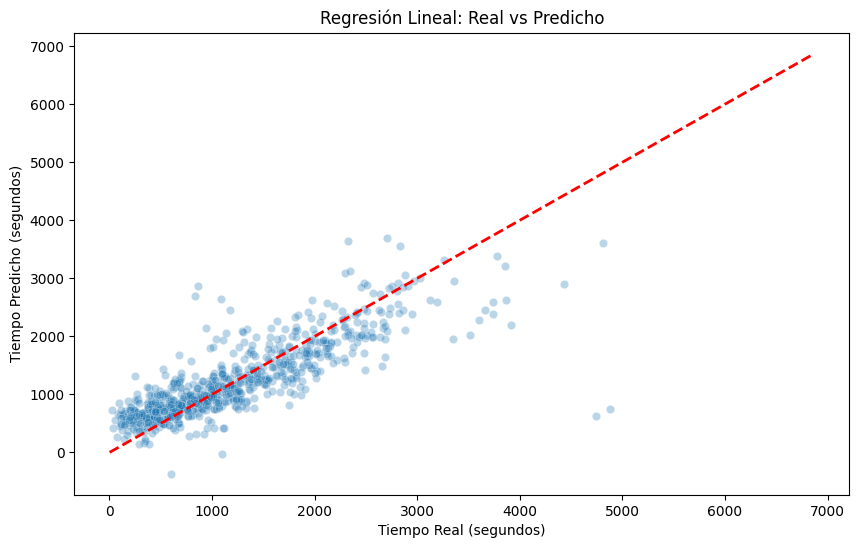

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Línea de perfección
plt.xlabel('Tiempo Real (segundos)')
plt.ylabel('Tiempo Predicho (segundos)')
plt.title('Regresión Lineal: Real vs Predicho')
plt.show()

### 3.2 MODELO RANDOM FOREST

In [11]:
#hacemos lo mismo que el anterior modelo
df_model = transfo_df.dropna(subset=['tiempo_etapa']).copy()
features = [
    'dist_ruta_paraderos',
    'dist_eucl_paraderos',
    'tipo_transporte',
    'time_type',
    'comuna_subida'
]

X = df_model[features]
y = df_model['tiempo_etapa']

X = pd.get_dummies(X, columns=['tipo_transporte', 'time_type', 'comuna_subida'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ENTRENAMIENTO (RANDOM FOREST)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Resultados Random Forest:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")


Resultados Random Forest:
RMSE: 395.61
R2: 0.7638


Vemos que RMSE es 395.61 , mejor predicción que el RMSE de la reggresion lineal 460.14


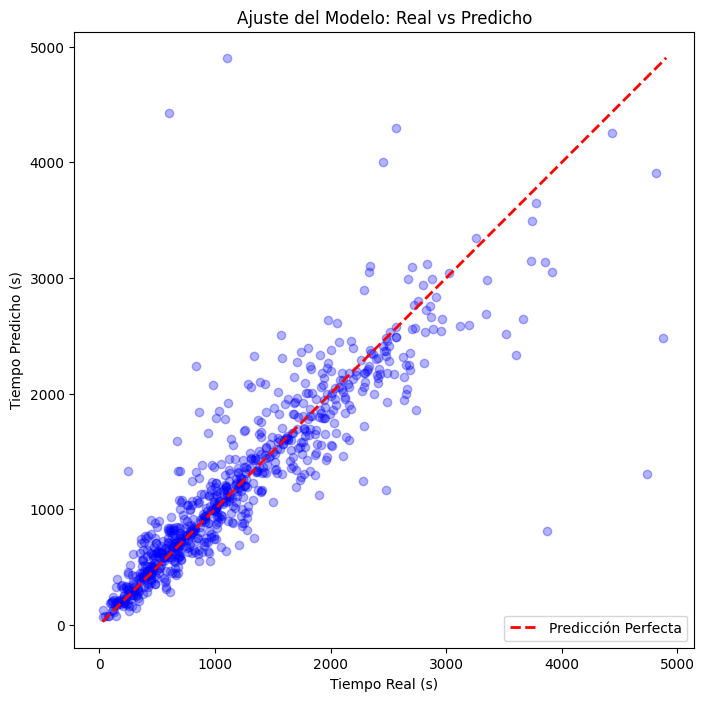

In [12]:
plt.figure(figsize=(8, 8))

# Gráfico de dispersión
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

plt.xlabel('Tiempo Real (s)')
plt.ylabel('Tiempo Predicho (s)')
plt.title('Ajuste del Modelo: Real vs Predicho')
plt.legend()
plt.axis('equal') 
plt.show()

### 3.3 MODELO GRADIENT BOOSTING REGRESSOR

In [13]:
target_col = 'tiempo_etapa' 
df_model = transfo_df.dropna(subset=[target_col]).copy()

features = [
    'dist_ruta_paraderos',
    'dist_eucl_paraderos',
    'tipo_transporte',
    'time_type',
    'comuna_subida'
]

X = df_model[features]
y = df_model[target_col]


X = pd.get_dummies(X, columns=['tipo_transporte', 'time_type', 'comuna_subida'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#ENTRENAMIENTO (GRADIENT BOOSTING)
gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5,        
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Resultados Gradient Boosting:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")


Resultados Gradient Boosting:
RMSE: 422.00
R2: 0.7312


##### Visualizacion

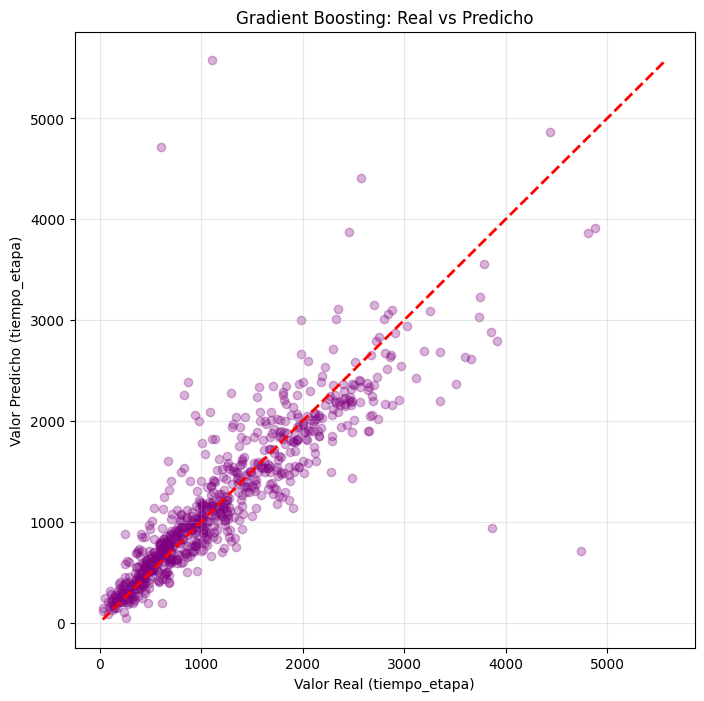

In [14]:

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel(f'Valor Real ({target_col})')
plt.ylabel(f'Valor Predicho ({target_col})')
plt.title(f'Gradient Boosting: Real vs Predicho')
plt.grid(True, alpha=0.3)
plt.show()